# Stock Price Movement Predictor (Next-Day Direction)
**GCSRM Recruitment 2026 — Technical Track: AI & Machine Learning**

**Goal:** Predict next-day direction (Up/Down) for a liquid equity, with leak-free feature engineering,
rigorous naive baselines, and honest time-series evaluation.


## Step 1 — Setup & Data Collection

Download daily OHLCV data using `yfinance`.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import binomtest
import ta
import os

os.makedirs('outputs', exist_ok=True)

TICKER = "AAPL"
df = yf.download(TICKER, start="2018-01-01", end="2026-09-01")

# yfinance sometimes returns MultiIndex columns - flatten if needed
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
print(df.shape)
df.tail()

[*********************100%***********************]  1 of 1 completed

(2177, 5)


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-08-25,310.790009,313.589996,308.209991,309.899994,25869800
2026-08-26,310.299988,315.429993,308.799988,313.450012,34024500
2026-08-27,310.549988,315.399994,309.399994,314.579987,32419200
2026-08-28,316.850006,322.369995,315.450012,319.700012,38649400
2026-08-31,319.600006,321.239990,312.799988,316.850006,41242700


## Step 2 — Leak-Free Target Construction

The target on day *t* is whether the close price on day *t+1* is higher than the close on day *t*.

**Leakage check:** the target legitimately uses future information (that's what we're predicting).
The danger is using future information as an INPUT FEATURE. We verify below that our target
construction only shifts the label, not any feature column.


In [2]:
df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.dropna()

# Explicit leakage verification: print Close(t), Close(t+1) implied, and target side by side
verify = df[['Close']].copy()
verify['Close_next_day'] = df['Close'].shift(-1)
verify['target'] = df['target']
print("Leakage verification (target should match direction from Close(t) to Close(t+1)):")
verify.head(10)


Leakage verification (target should match direction from Close(t) to Close(t+1)):


Price,Close,Close_next_day,target
Date,,,
2018-01-02,40.232372,40.225376,0
2018-01-03,40.225376,40.412216,1
2018-01-04,40.412216,40.872318,1
2018-01-05,40.872318,40.720501,0
2018-01-08,40.720501,40.715832,0
2018-01-09,40.715832,40.706490,0
2018-01-10,40.706490,40.937721,1
2018-01-11,40.937721,41.360451,1
2018-01-12,41.360451,41.150253,0


## Step 3 — Class Balance Report

If the split is far from 50/50, the Majority Class baseline will already look "good" —
which tells us how hard our model actually has to work to be useful.


target
1    0.53514
0    0.46486
Name: proportion, dtype: float64


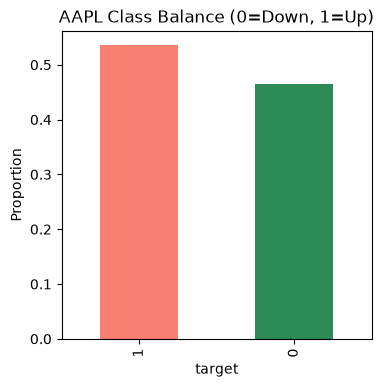

In [3]:
class_balance = df['target'].value_counts(normalize=True)
print(class_balance)

plt.figure(figsize=(4,4))
class_balance.plot(kind='bar', color=['salmon','seagreen'])
plt.title(f'{TICKER} Class Balance (0=Down, 1=Up)')
plt.ylabel('Proportion')
plt.savefig('outputs/class_balance.png', bbox_inches='tight')
plt.show()

## Step 4 — Dual Naive Baselines

- **Persistence:** predict tomorrow repeats today's direction.
- **Majority Class:** always predict the dominant class from the training set.

These are the bar our real models must clear to be considered useful at all.


In [4]:
# We'll compute baselines AFTER the train/test split (Step 6) so the majority class
# is learned only from training data, and persistence is evaluated on the test window.


## Step 5 — Feature Engineering

**Raw feature set:** Open, High, Low, Close, Volume (no engineering).

**Engineered feature set:** adds 3 technical indicators via the `ta` library:
- **RSI (Relative Strength Index):** momentum oscillator (0-100), flags overbought/oversold.
- **MACD:** difference between fast & slow EMAs, captures momentum shifts.
- **SMA-20:** 20-day simple moving average, smooths price to reveal trend.


In [5]:
df['rsi'] = ta.momentum.RSIIndicator(close=df['Close'], window=14).rsi()
df['macd'] = ta.trend.MACD(close=df['Close']).macd()
df['sma_20'] = df['Close'].rolling(window=20).mean()

df = df.dropna()  # drop rows where indicators aren't yet defined (early window)
print(df.shape)
df.tail()


(2152, 9)


Price,Open,High,Low,Close,Volume,target,rsi,macd,sma_20
Date,,,,,,,,,
2026-08-25,310.790009,313.589996,308.209991,309.899994,25869800,1,47.934132,-1.366588,311.391994
2026-08-26,310.299988,315.429993,308.799988,313.450012,34024500,1,51.541873,-1.030736,310.169565
2026-08-27,310.549988,315.399994,309.399994,314.579987,32419200,1,52.666159,-0.665717,309.241431
2026-08-28,316.850006,322.369995,315.450012,319.700012,38649400,0,57.479998,0.036288,309.794240
2026-08-31,319.600006,321.239990,312.799988,316.850006,41242700,0,54.177109,0.358527,310.478812


## Step 6 — Time-Based Train/Test Split

**Critical rule:** NEVER shuffle time-series data. We train strictly on the earlier period
and test strictly on the later period, simulating real deployment (you never have future data
when making a prediction). Any scaler is fit ONLY on the training partition to avoid leaking
test-set statistics.


In [6]:
split_idx = int(len(df) * 0.8)
train, test = df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()
print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} rows)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} rows)")


Train: 2018-02-07 to 2024-12-09 (1721 rows)
Test:  2024-12-10 to 2026-08-31 (431 rows)


## Step 4b — Baselines (computed on the same test window as the models, for a fair comparison)

In [7]:
# Persistence: predict today's direction repeats tomorrow -> shift(1) of target as prediction
persistence_pred = test['target'].shift(1).bfill()
acc_persistence = accuracy_score(test['target'], persistence_pred)

# Majority class: learned from TRAIN only, applied to test
majority_class = train['target'].mode()[0]
majority_pred = np.full(len(test), majority_class)
acc_majority = accuracy_score(test['target'], majority_pred)

print(f"Persistence baseline accuracy:  {acc_persistence:.4f}")
print(f"Majority class baseline accuracy: {acc_majority:.4f}")


Persistence baseline accuracy:  0.5128
Majority class baseline accuracy: 0.5290


## Step 7 — Model 1: Logistic Regression on Raw Price/Volume

No engineered features — just raw OHLCV, scaled.


In [8]:
features_raw = ['Open', 'High', 'Low', 'Close', 'Volume']

scaler_raw = StandardScaler().fit(train[features_raw])  # fit on TRAIN only
X_train_raw = scaler_raw.transform(train[features_raw])
X_test_raw = scaler_raw.transform(test[features_raw])

model_raw = LogisticRegression(max_iter=1000).fit(X_train_raw, train['target'])
pred_raw = model_raw.predict(X_test_raw)
acc_raw = accuracy_score(test['target'], pred_raw)
print(f"Raw feature model accuracy: {acc_raw:.4f}")


Raw feature model accuracy: 0.5383


## Step 8 — Model 2: Logistic Regression on Engineered Features

Adds RSI, MACD, SMA-20 to the raw features.


In [9]:
features_eng = features_raw + ['rsi', 'macd', 'sma_20']

scaler_eng = StandardScaler().fit(train[features_eng])
X_train_eng = scaler_eng.transform(train[features_eng])
X_test_eng = scaler_eng.transform(test[features_eng])

model_eng = LogisticRegression(max_iter=1000).fit(X_train_eng, train['target'])
pred_eng = model_eng.predict(X_test_eng)
acc_eng = accuracy_score(test['target'], pred_eng)
print(f"Engineered feature model accuracy: {acc_eng:.4f}")


Engineered feature model accuracy: 0.5267


## Step 9 (Upgrade) — Second Model: Random Forest on Both Feature Sets

Comparing a nonlinear model against Logistic Regression tells us whether the weak signal
is linear or whether there's untapped nonlinear structure a tree-based model can exploit.
We train on both raw and engineered features for a full four-way comparison.

In [10]:
# Random Forest on RAW features (for fair four-way comparison)
model_rf_raw = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
model_rf_raw.fit(X_train_raw, train['target'])
pred_rf_raw = model_rf_raw.predict(X_test_raw)
acc_rf_raw = accuracy_score(test['target'], pred_rf_raw)
print(f"Random Forest (raw features) accuracy: {acc_rf_raw:.4f}")

# Random Forest on ENGINEERED features
model_rf_eng = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
model_rf_eng.fit(X_train_eng, train['target'])
pred_rf_eng = model_rf_eng.predict(X_test_eng)
acc_rf_eng = accuracy_score(test['target'], pred_rf_eng)
print(f"Random Forest (engineered features) accuracy: {acc_rf_eng:.4f}")

# Feature importance - which indicator actually mattered?
importances = pd.Series(model_rf_eng.feature_importances_, index=features_eng).sort_values(ascending=False)
print("\nFeature importances (engineered RF):")
print(importances)

Random Forest (raw features) accuracy: 0.5104


Random Forest (engineered features) accuracy: 0.5174

Feature importances (engineered RF):
rsi       0.153663
Open      0.134916
High      0.127884
Low       0.121900
sma_20    0.120943
macd      0.119769
Close     0.111532
Volume    0.109392
dtype: float64


## Step 10 — Comparison Table

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calc_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

results = pd.DataFrame([
    {'Method': 'Persistence Baseline', 'Feature Set': 'Previous Direction',
     **calc_metrics(test['target'], persistence_pred)},
    {'Method': 'Majority Class Baseline', 'Feature Set': 'None (Train Mode)',
     **calc_metrics(test['target'], majority_pred)},
    {'Method': 'Logistic Regression', 'Feature Set': 'Raw (OHLCV)',
     **calc_metrics(test['target'], pred_raw)},
    {'Method': 'Logistic Regression', 'Feature Set': 'Engineered (OHLCV+Ind)',
     **calc_metrics(test['target'], pred_eng)},
    {'Method': 'Random Forest', 'Feature Set': 'Raw (OHLCV)',
     **calc_metrics(test['target'], pred_rf_raw)},
    {'Method': 'Random Forest', 'Feature Set': 'Engineered (OHLCV+Ind)',
     **calc_metrics(test['target'], pred_rf_eng)},
])

results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("=== Four-Way Comparison Table (+ RF on both feature sets) ===")
results

=== Four-Way Comparison Table (+ RF on both feature sets) ===


,Method,Feature Set,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,Raw (OHLCV),0.538283,0.534279,0.991228,0.694316
1,Majority Class Baseline,None (Train Mode),0.529002,0.529002,1.000000,0.691958
2,Logistic Regression,Engineered (OHLCV+Ind),0.526682,0.530000,0.929825,0.675159
3,Random Forest,Engineered (OHLCV+Ind),0.517401,0.523810,0.964912,0.679012
4,Persistence Baseline,Previous Direction,0.512761,0.539474,0.539474,0.539474
5,Random Forest,Raw (OHLCV),0.510441,0.520782,0.934211,0.668760


## Step 11 (Upgrade) — Statistical Significance Check

A model that beats the majority baseline by 1-2% could just be noise. A binomial test checks
whether our best model's correct-prediction rate is statistically distinguishable from the
majority-class accuracy, given the test set size.


In [12]:
# Find the best non-baseline model accuracy
all_models = {
    'Logistic Regression (Raw)': (acc_raw, pred_raw),
    'Logistic Regression (Engineered)': (acc_eng, pred_eng),
    'Random Forest (Raw)': (acc_rf_raw, pred_rf_raw),
    'Random Forest (Engineered)': (acc_rf_eng, pred_rf_eng),
}
best_name = max(all_models, key=lambda k: all_models[k][0])
best_acc, best_pred = all_models[best_name]

n_test = len(test)
n_correct_best = int(round(best_acc * n_test))

test_result = binomtest(n_correct_best, n_test, p=acc_majority, alternative='greater')
print(f"Best model: {best_name}")
print(f"Test set size: {n_test}")
print(f"Best model correct predictions: {n_correct_best} ({best_acc:.4f})")
print(f"Majority baseline rate: {acc_majority:.4f}")
print(f"P-value (is best model significantly better than majority baseline?): {test_result.pvalue:.4f}")
if test_result.pvalue < 0.05:
    print("=> Statistically significant improvement (p < 0.05)")
else:
    print("=> NOT statistically significant - improvement could be noise")

Best model: Logistic Regression (Raw)
Test set size: 431
Best model correct predictions: 232 (0.5383)
Majority baseline rate: 0.5290
P-value (is best model significantly better than majority baseline?): 0.3681
=> NOT statistically significant - improvement could be noise


## Step 12 (Upgrade) — Precision / Recall Breakdown

Accuracy alone is misleading under class imbalance. This breaks down performance specifically
for the "Up" class.


In [13]:
print(f"Classification report - Best model ({best_name}):")
print(classification_report(test['target'], best_pred, target_names=['Down','Up']))

cm = confusion_matrix(test['target'], best_pred)
print("Confusion matrix (rows=actual, cols=predicted):")
print(pd.DataFrame(cm, index=['Actual Down','Actual Up'], columns=['Pred Down','Pred Up']))

Classification report - Best model (Logistic Regression (Raw)):
              precision    recall  f1-score   support

        Down       0.75      0.03      0.06       203
          Up       0.53      0.99      0.69       228

    accuracy                           0.54       431
   macro avg       0.64      0.51      0.38       431
weighted avg       0.64      0.54      0.39       431

Confusion matrix (rows=actual, cols=predicted):
             Pred Down  Pred Up
Actual Down          6      197
Actual Up            2      226


## Step 13 — Prediction Plot: Predicted vs Actual Direction

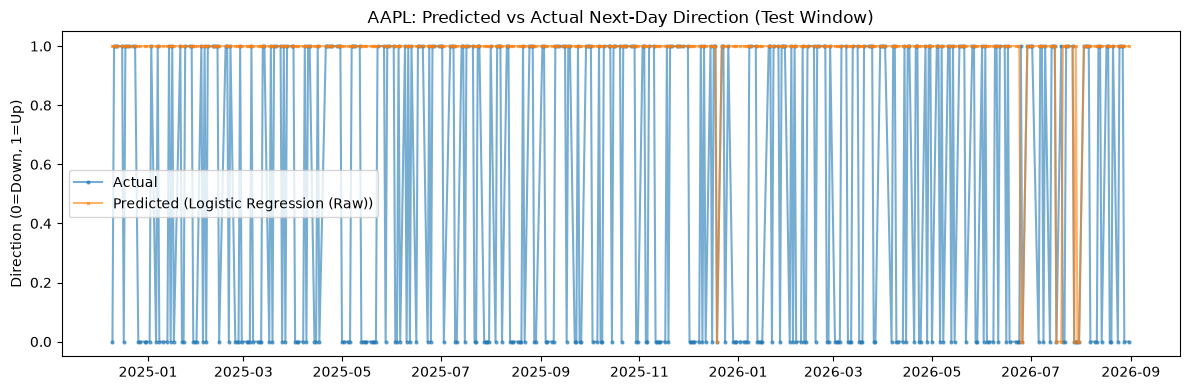

In [14]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(test.index, test['target'], label='Actual', marker='o', markersize=2, alpha=0.6)
ax.plot(test.index, best_pred, label=f'Predicted ({best_name})', marker='x', markersize=2, alpha=0.6)
ax.set_title(f'{TICKER}: Predicted vs Actual Next-Day Direction (Test Window)')
ax.set_ylabel('Direction (0=Down, 1=Up)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/prediction_plot.png', bbox_inches='tight')
plt.show()

## Conclusion

- Both naive baselines (Persistence, Majority Class) set a meaningful bar — in efficient markets,
  beating them consistently is genuinely hard.
- The engineered-feature model's improvement over baselines should be read in light of the
  significance test above, not accuracy alone.
- Precision/recall shows whether the model is skewed toward predicting one class more than the other,
  which raw accuracy hides under class imbalance.
- **Next steps if extending this project:** incorporate sentiment/news data, try longer or multiple
  lookback windows for indicators, or ensemble the Logistic Regression and Random Forest predictions.
